In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import os

In [ ]:
img_path = 'image.jpg'
if os.path.exists(img_path):
  img = cv2.imread(img_path)

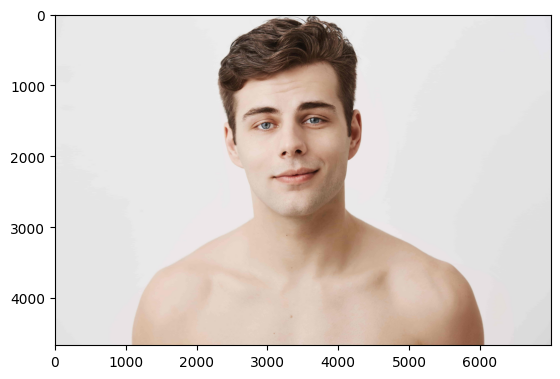

In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)


🎨 RGB:
   Канал 0: 1 - 255
   Канал 1: 0 - 249
   Канал 2: 0 - 255

🎨 Grayscale:
   Значения: 0 - 250

🎨 HSV:
   Канал 0: 0 - 179
   Канал 1: 0 - 255
   Канал 2: 1 - 255

🎨 LAB:
   Канал 0: 0 - 250
   Канал 1: 121 - 172
   Канал 2: 113 - 163


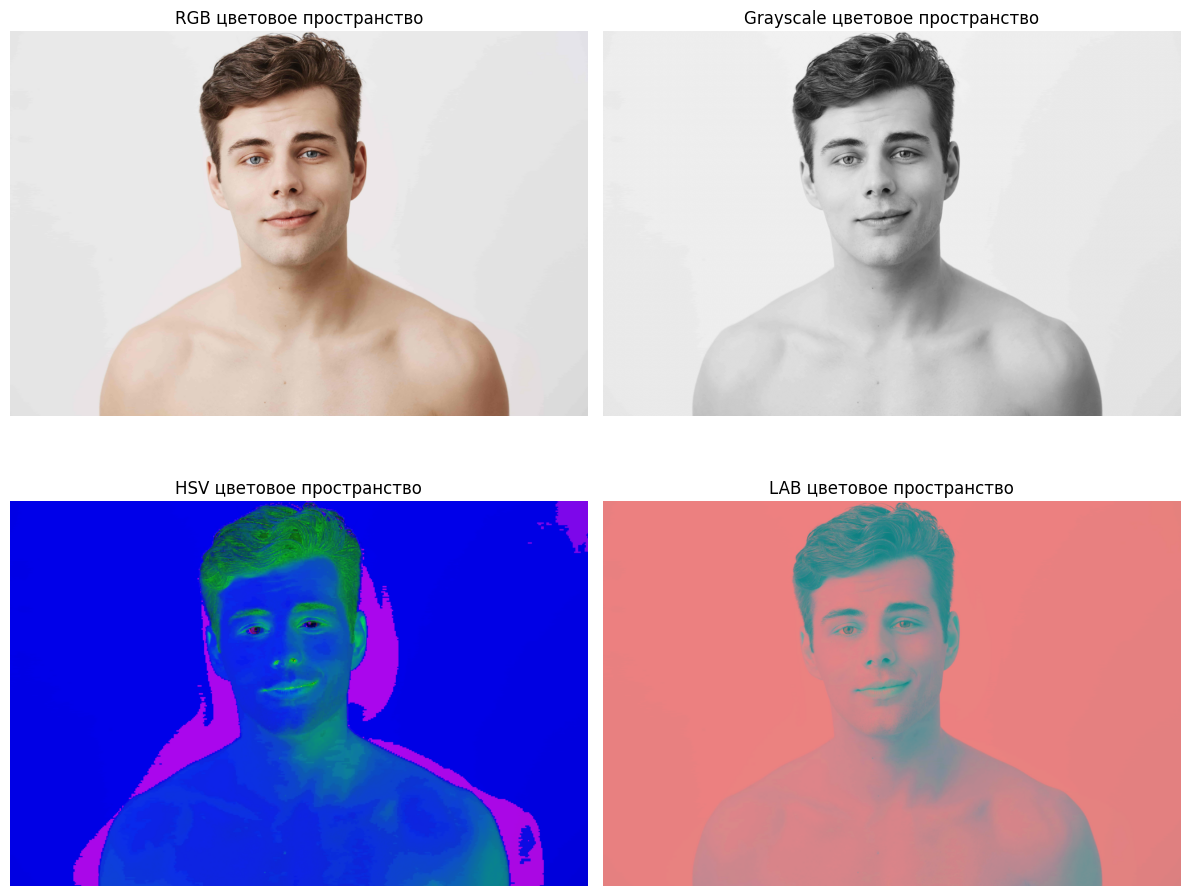

In [ ]:
conversions = {
    'RGB': (cv2.cvtColor(img, cv2.COLOR_BGR2RGB), None),
    'Grayscale': (cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 'gray'),
    'HSV': (cv2.cvtColor(img, cv2.COLOR_BGR2HSV), None),
    'LAB': (cv2.cvtColor(img, cv2.COLOR_BGR2LAB), None)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, (image, cmap)) in enumerate(conversions.items()):
    axes[i].imshow(image, cmap=cmap)
    axes[i].set_title(f'{name} цветовое пространство')
    axes[i].axis('off')

    # Выводим диапазоны значений
    print(f"\n🎨 {name}:")
    if len(image.shape) == 3:
        for ch in range(image.shape[2]):
            print(f"   Канал {ch}: {image[:,:,ch].min()} - {image[:,:,ch].max()}")
    else:
        print(f"   Значения: {image.min()} - {image.max()}")

plt.tight_layout()
plt.show()

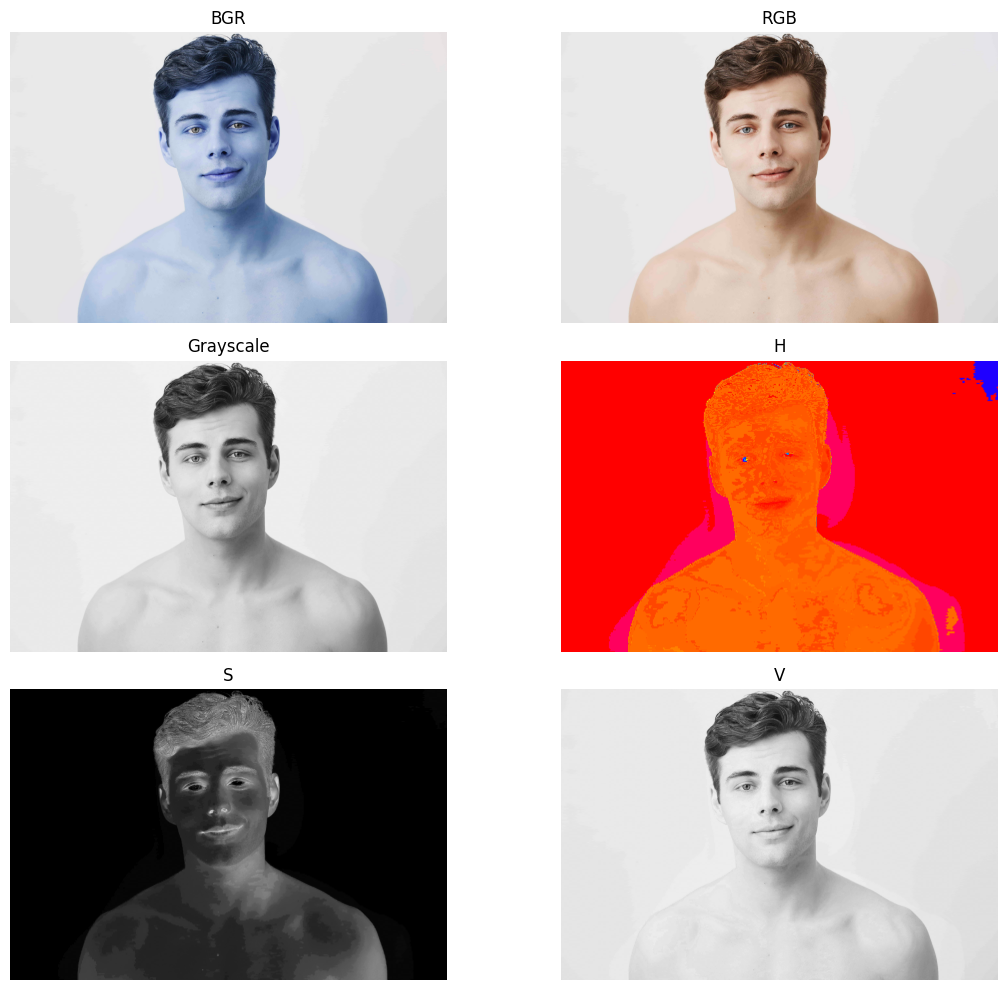

In [ ]:
h, s, v = cv2.split(cv2.cvtColor(img, cv2.COLOR_BGR2HSV))
conversions ={
    'BGR': (img, None),
    'RGB': (cv2.cvtColor(img, cv2.COLOR_BGR2RGB), None),
    'Grayscale': (cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 'gray'),
    'H': (h, 'hsv'),
    'S': (s, 'gray'),
    'V': (v, 'gray')
}

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, (image, cmap)) in enumerate(conversions.items()):
    axes[i].imshow(image, cmap=cmap)
    axes[i].set_title(f'{name}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

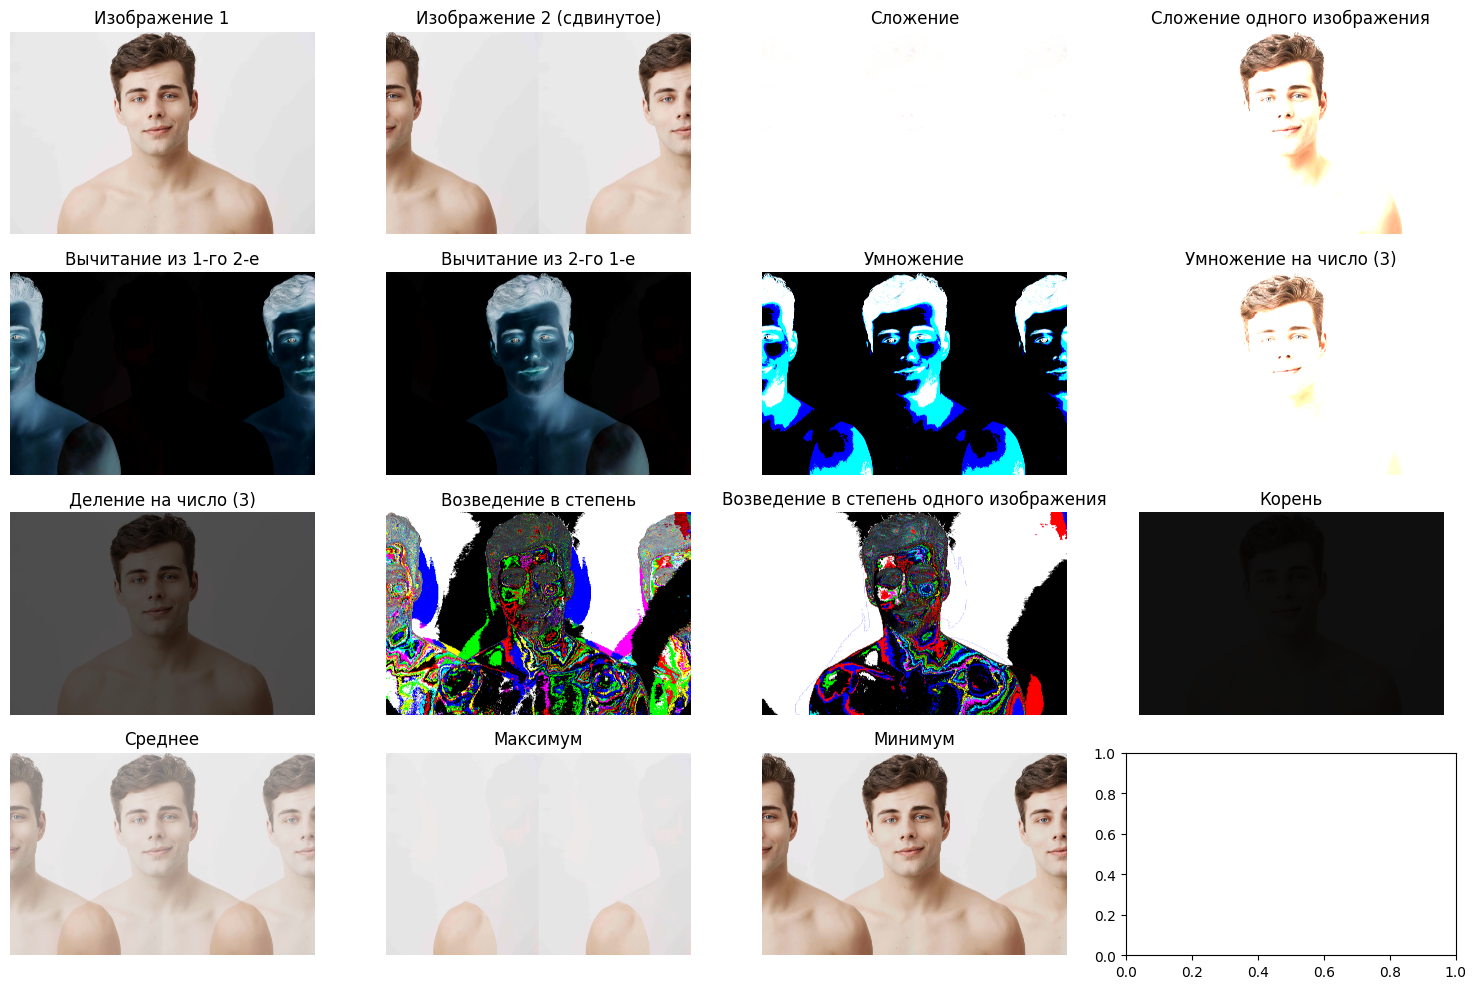

In [ ]:
img1 = img_rgb.copy()
img2 = np.roll(img1, img1.shape[1] // 2, axis=1)
operations = {
    'Сложение': np.clip(img1.astype(np.int16) + img2.astype(np.int16), 0, 255).astype(np.uint8),
    'Сложение одного изображения': np.clip(img1.astype(np.int16) + img1.astype(np.int16), 0, 255).astype(np.uint8),
    'Вычитание из 1-го 2-е': np.clip(img1.astype(np.int16) - img2.astype(np.int16), 0, 255).astype(np.uint8),
    'Вычитание из 2-го 1-е': np.clip(img2.astype(np.int16) - img1.astype(np.int16), 0, 255).astype(np.uint8),
    'Умножение': np.clip(img1.astype(np.int16) * img2.astype(np.int16), 0, 255).astype(np.uint8),
    'Умножение на число (3)': np.clip(img1.astype(np.int16) * 3, 0, 255).astype(np.uint8),
    'Деление на число (3)': np.clip(img1.astype(np.int16) / 3, 0, 255).astype(np.uint8),
    'Возведение в степень': np.clip(img1.astype(np.int16) ** img2.astype(np.int16), 0, 255).astype(np.uint8),
    'Возведение в степень одного изображения': np.clip(img1.astype(np.int16) ** img1.astype(np.int16), 0, 255).astype(np.uint8),
    'Корень': np.clip(img1.astype(np.int16) ** 0.5, 0, 255).astype(np.uint8),
    'Среднее': ((img1.astype(np.int16) + img2.astype(np.int16)) // 2).astype(np.uint8),
    'Максимум': np.maximum(img1, img2),
    'Минимум': np.minimum(img1, img2),
}

fig, axes = plt.subplots(4, 4, figsize=(15, 10))
axes = axes.flatten()

axes[0].imshow(img1)
axes[0].set_title('Изображение 1')
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title('Изображение 2 (сдвинутое)')
axes[1].axis('off')

for i, (name, result) in enumerate(operations.items(), 2):
    axes[i].imshow(result)
    axes[i].set_title(name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

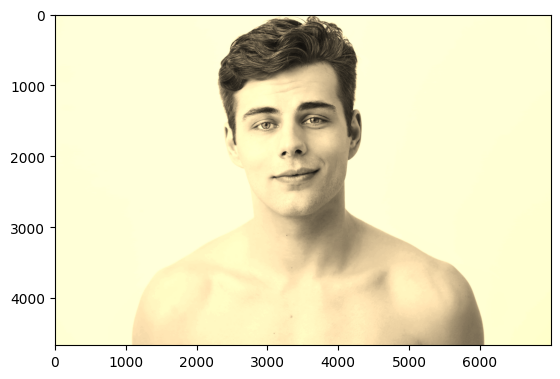

In [ ]:
img = cv2.imread('image.jpg')
def image_sepia(img):
    sepia_kernel = np.array([[0.393, 0.769, 0.189], [0.349, 0.686, 0.168], [0.272, 0.534, 0.131]])
    sepia_image = cv2.transform(img, sepia_kernel)
    return sepia_image
plt.imshow(image_sepia(img))